#### Base de dados (tabela DN)
https://datasus.saude.gov.br/transferencia-de-arquivos


<h1 align="center">Predição do peso ao nascer em Minas Gerais utilizando modelos de regressão a partir dos dados da SINASC</h1>

---

## Problema

Predizer o risco de baixo peso ao nascer (<2500g) em nascidos vivos em Minas Gerais no período de 2020-2024, utilizando dados socioeconômicos e clínicos disponíveis até o momento do parto com dados da base SINASC da tabela DN.  

É um problema de regressão, com base clínica sólida na literatura (fator de risco reconhecido para mortalidade neonatal), desbalanceamento de classes (~8-10% de baixo peso no Brasil).

## Escopo

| Parâmetro | Definição |
|---|---|
| **Fonte** | SINASC (tabela DN)
| **UF** | Minas Gerais (MG) |
| **Período** | 2020–2024 (5 anos) |
| **Unidade de análise** | 1 registro = 1 nascido vivo |
| **Target** | `PESO < 2500`|

---

### Importando bibliotecas

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from datetime import datetime
import os

### Lendo os arquivos

In [36]:
# Todos os arquivos csv da pasta data
arquivos_csv = [f for f in os.listdir('data') if f.endswith('.csv')]

dfs = []
for arquivo in arquivos_csv:
    path = os.path.join('data', arquivo)
    df = pd.read_csv(path)
    df['origem'] = arquivo
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()

C:\Users\Max\AppData\Local\Temp\ipykernel_14740\3530333382.py:7: DtypeWarning: Columns (32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,DTDECLARAC,ESCMAEAGR1,STDNEPIDEM,STDNNOVA,CODPAISRES,TPROBSON,PARIDADE,KOTELCHUCK,CONTADOR,origem
0,1,2495228.0,110028,1,19,2.0,4.0,621005.0,1.0,3.0,...,12012020.0,6.0,0,1,1,11,1,4,10480,DNMG2020.csv
1,1,2456613.0,210530,1,21,1.0,5.0,999991.0,0.0,0.0,...,1022020.0,7.0,0,1,1,2,0,2,169378,DNMG2020.csv
2,1,2456893.0,211130,1,29,1.0,5.0,999991.0,1.0,1.0,...,NaN,7.0,0,1,1,3,1,5,194775,DNMG2020.csv
3,1,6553567.0,211230,1,32,2.0,4.0,621005.0,1.0,0.0,...,10042020.0,5.0,0,1,1,5,1,5,198579,DNMG2020.csv
4,1,2319454.0,260790,1,25,1.0,4.0,999992.0,1.0,0.0,...,7012020.0,12.0,0,1,1,5,1,2,357523,DNMG2020.csv


In [37]:
# Filtrandos as features que serão utilizadas
filtro = ['IDADEMAE', 
          'ESTCIVMAE', 
          'ESCMAE2010', 
          'QTDFILVIVO', 
          'QTDFILMORT', 
          'QTDGESTANT', 
          'QTDPARTNOR', 
          'QTDPARTCES', 
          'PARIDADE', 
          'GRAVIDEZ', 
          'SEMAGESTAC', 
          'KOTELCHUCK', 
          'CONSPRENAT', 
          'MESPRENAT', 
          'SEXO', 
          'DTNASC',
          'PESO'] # <- Target

df = df[filtro]

In [38]:
# Sumario das variáveis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178134 entries, 0 to 1178133
Data columns (total 17 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   IDADEMAE    1178134 non-null  int64  
 1   ESTCIVMAE   1172467 non-null  float64
 2   ESCMAE2010  1169266 non-null  float64
 3   QTDFILVIVO  1166936 non-null  float64
 4   QTDFILMORT  1163351 non-null  float64
 5   QTDGESTANT  1164011 non-null  float64
 6   QTDPARTNOR  1161668 non-null  float64
 7   QTDPARTCES  1161530 non-null  float64
 8   PARIDADE    1178134 non-null  int64  
 9   GRAVIDEZ    1177452 non-null  float64
 10  SEMAGESTAC  1168427 non-null  float64
 11  KOTELCHUCK  1178134 non-null  int64  
 12  CONSPRENAT  1164948 non-null  float64
 13  MESPRENAT   1157142 non-null  float64
 14  SEXO        1178134 non-null  int64  
 15  DTNASC      1178134 non-null  int64  
 16  PESO        1178100 non-null  float64
dtypes: float64(12), int64(5)
memory usage: 152.8 MB


Podemos ver os tipos das variáveis e que também há dados nulos.

### Verificando dados nulos

In [39]:
display(df.isnull().sum().sum(), df.isnull().sum())

np.int64(132310)

IDADEMAE          0
ESTCIVMAE      5667
ESCMAE2010     8868
QTDFILVIVO    11198
QTDFILMORT    14783
QTDGESTANT    14123
QTDPARTNOR    16466
QTDPARTCES    16604
PARIDADE          0
GRAVIDEZ        682
SEMAGESTAC     9707
KOTELCHUCK        0
CONSPRENAT    13186
MESPRENAT     20992
SEXO              0
DTNASC            0
PESO             34
dtype: int64

Nosso dataframe tem 132310 dados nulos, cada coluna deve ser tratada individualmente.

In [40]:
# Sumario das variáveis  
df.describe().apply(lambda s: s.apply('{:.2f}'.format))
#             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ desativa anotação cientifica

,IDADEMAE,ESTCIVMAE,ESCMAE2010,QTDFILVIVO,QTDFILMORT,QTDGESTANT,QTDPARTNOR,QTDPARTCES,PARIDADE,GRAVIDEZ,SEMAGESTAC,KOTELCHUCK,CONSPRENAT,MESPRENAT,SEXO,DTNASC,PESO
count,1178134.00,1172467.00,1169266.00,1166936.00,1163351.00,1164011.00,1161668.00,1161530.00,1178134.00,1177452.00,1168427.00,1178134.00,1164948.00,1157142.00,1178134.00,1178134.00,1178100.00
mean,28.16,1.89,3.28,0.90,0.25,1.14,0.54,0.38,0.61,1.03,38.30,4.63,9.10,4.36,1.49,15746489.03,3117.40
std,6.66,1.23,1.06,1.11,0.62,1.33,1.05,0.70,0.49,0.16,2.18,1.36,4.98,14.13,0.50,8772539.60,549.76
min,10.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,19.00,1.00,0.00,1.00,0.00,1012020.00,100.00
25%,23.00,1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,38.00,5.00,7.00,1.00,1.00,8072022.00,2850.00
50%,28.00,2.00,3.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,39.00,5.00,9.00,2.00,1.00,16022024.00,3160.00
75%,33.00,2.00,4.00,1.00,0.00,2.00,1.00,1.00,1.00,1.00,39.00,5.00,10.00,3.00,2.00,23092022.00,3455.00
max,99.00,9.00,9.00,99.00,99.00,99.00,99.00,99.00,1.00,9.00,45.00,9.00,99.00,99.00,2.00,31122024.00,7000.00


In [41]:
# Preenchendo os valores nulos com a mediana
for col in df.columns:
    df.loc[df[col].isna(), col] = df[col].median()

In [42]:
# Avaliando a quantidade de dados duplicados
df[df.duplicated()]

,IDADEMAE,ESTCIVMAE,ESCMAE2010,QTDFILVIVO,QTDFILMORT,QTDGESTANT,QTDPARTNOR,QTDPARTCES,PARIDADE,GRAVIDEZ,SEMAGESTAC,KOTELCHUCK,CONSPRENAT,MESPRENAT,SEXO,DTNASC,PESO
1107,33,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2.0,33.0,5,9.0,1.0,1,17022020,1835.0
2852,34,2.0,5.0,1.0,0.0,1.0,0.0,1.0,1,2.0,36.0,5,14.0,2.0,2,3012020,2430.0
4585,36,5.0,3.0,3.0,1.0,4.0,3.0,0.0,1,1.0,39.0,9,4.0,99.0,2,28042020,4165.0
5831,28,2.0,3.0,1.0,0.0,1.0,1.0,0.0,1,1.0,39.0,5,11.0,1.0,2,9022020,3490.0
24560,28,1.0,5.0,0.0,0.0,0.0,0.0,0.0,0,1.0,37.0,5,7.0,2.0,2,14052020,2125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138212,20,1.0,3.0,1.0,0.0,1.0,0.0,1.0,1,3.0,30.0,2,8.0,4.0,2,18082024,1320.0
1142592,42,2.0,5.0,2.0,2.0,4.0,0.0,2.0,1,1.0,39.0,5,7.0,1.0,1,16082024,3975.0
1145174,34,2.0,5.0,1.0,0.0,1.0,0.0,1.0,1,1.0,38.0,5,7.0,2.0,1,17082024,3210.0
1170932,33,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0,2.0,36.0,5,11.0,1.0,1,26072024,2260.0


In [43]:
# Verificando a proporção das variáveis de classe
display(round(df['ESTCIVMAE'].value_counts(normalize=True)*100, 2), 
        round(df['ESCMAE2010'].value_counts(normalize=True)*100,2), 
        round(df['GRAVIDEZ'].value_counts(normalize=True)*100,2), 
        round(df['SEXO'].value_counts(normalize=True)*100, 2))

ESTCIVMAE
1.0    45.92
2.0    42.07
5.0     9.37
4.0     2.15
9.0     0.28
3.0     0.22
Name: proportion, dtype: float64

ESCMAE2010
3.0    56.48
5.0    20.92
2.0    15.63
4.0     4.84
1.0     1.83
9.0     0.17
0.0     0.12
Name: proportion, dtype: float64

GRAVIDEZ
1.0    97.51
2.0     2.42
3.0     0.06
9.0     0.00
Name: proportion, dtype: float64

SEXO
1    51.13
2    48.86
0     0.01
Name: proportion, dtype: float64

A proporção das classes, principalmente aquelas que informam a quantidade ignorada, está proporcionalmente baixas.

Vamos ver como está a distribuição da variável **target**:

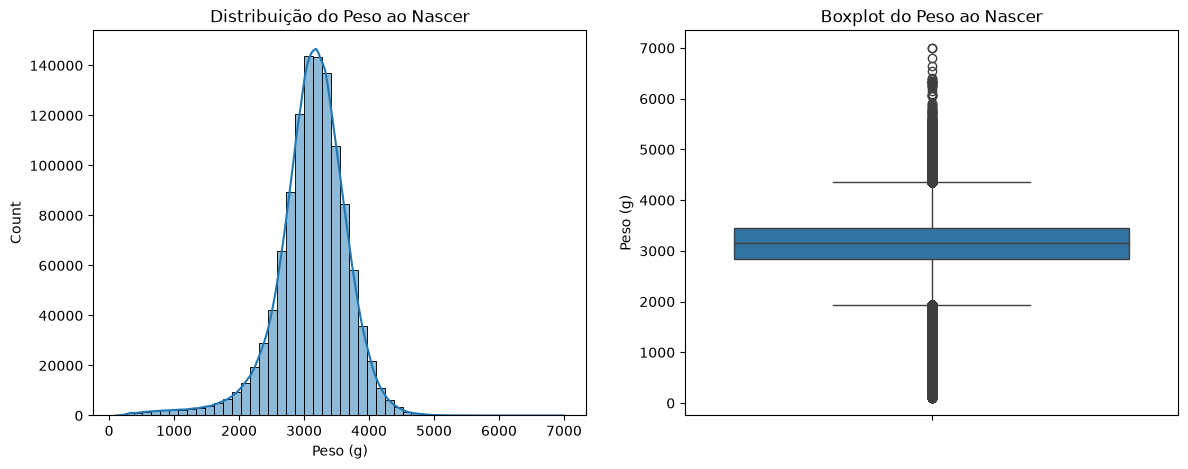

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma com curva de densidade
sns.histplot(df['PESO'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Peso ao Nascer')
axes[0].set_xlabel('Peso (g)')

# Boxplot para visualizar outliers
sns.boxplot(y=df['PESO'], ax=axes[1])
axes[1].set_title('Boxplot do Peso ao Nascer')
axes[1].set_ylabel('Peso (g)')

plt.show()

Podemos ver que de fato a média do peso está por volta de 3100 gramas, com valores relativamente concentrados. Entretanto, existe valores para peso inferior a 500g e superior a 6000g, fora da literatura clinica, portanto são dados que devem estar sendo removidos do dataset.

Além disso, podemos ver a proporção de crianças abaixo de 2500g, segundo a taxa nacional, ela deve estar entre 8 a 10%.

In [45]:
# Proporção entre 8 a 10%
round((df['PESO'].shape[0]/ df[df['PESO'] < 2500].shape[0]), 2)

10.02

A proporção de crianças de MG abaixo de 2500g está entre a média nacional.

Verficando se o período de pandemia alterou as distribuições:

In [46]:
# Convertendo a data de nascimento para o tipo datetime
df['DTNASC'] = pd.to_datetime(df['DTNASC'], format='%d%m%Y', errors='coerce')

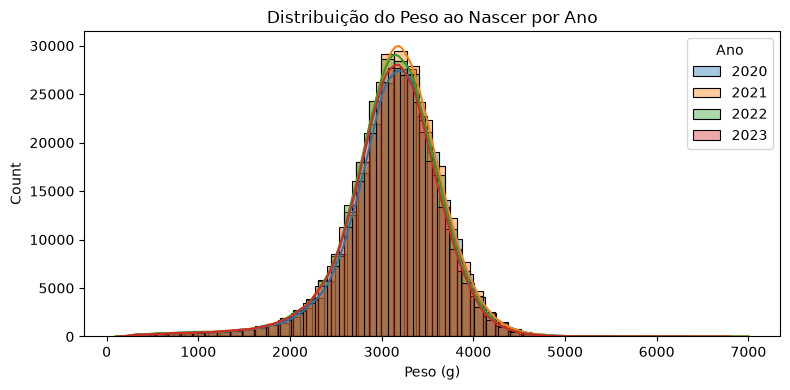

In [47]:
# Desenhando os gráficos
fig, ax = plt.subplots(figsize=(8, 4))

anos = [2020, 2021, 2022, 2023, 2024]
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ano, cor in zip(anos, cores):
    dados = df[(df['DTNASC'] >= f'{ano}-01-01') & (df['DTNASC'] <= f'{ano}-12-31')]['PESO']
    sns.histplot(dados, bins=50, kde=True, ax=ax, color=cor, label=str(ano), alpha=0.4)

ax.set_title('Distribuição do Peso ao Nascer por Ano')
ax.set_xlabel('Peso (g)')
ax.legend(title='Ano')

plt.tight_layout()
plt.show()

Pelas sobreposições dos gráficos, as distribuições permaneceram a mesma.

## **Distribuições**

Vamos explorar as distribuições de cada tipo de variável

### Categóricas

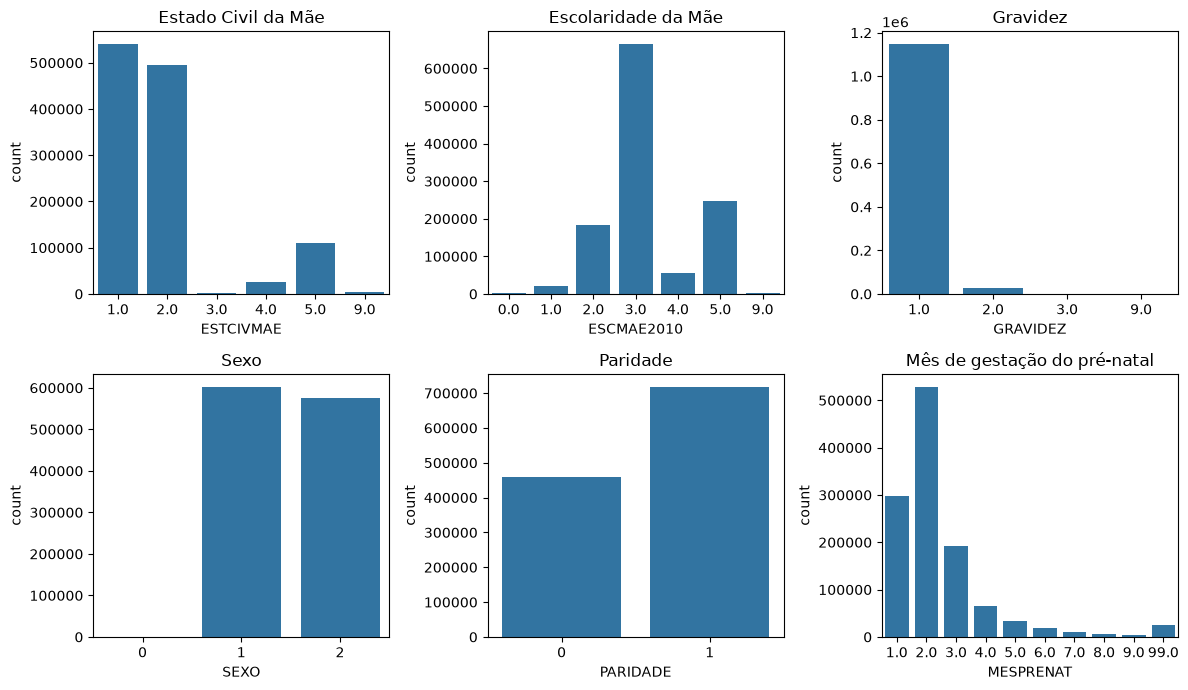

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

sns.countplot(x=df['ESTCIVMAE'], ax=axes[0,0])
axes[0,0].set_title('Estado Civil da Mãe')

sns.countplot(x=df['ESCMAE2010'], ax=axes[0,1])
axes[0,1].set_title('Escolaridade da Mãe')

sns.countplot(x=df['GRAVIDEZ'], ax=axes[0,2])
axes[0,2].set_title('Gravidez')

sns.countplot(x=df['SEXO'], ax=axes[1,0])
axes[1,0].set_title('Sexo')

sns.countplot(x=df['PARIDADE'], ax=axes[1,1])
axes[1,1].set_title('Paridade')

sns.countplot(x=df['MESPRENAT'], ax=axes[1,2])
axes[1,2].set_title('Mês de gestação do pré-natal')

plt.tight_layout()
plt.show()

### **Conclusões:**
- **Estado Civil da Mãe:** Concentração forte em 1 (Solteira) e 2 (Casada), ambas dominam o dataset. 5 (União estável) tem um volume relevante.
- **Escolaridade da Mãe:** Bem definido em 3 (Ensino Médio) com mais de 600 mil registros, seguido por superior completo.
- **Gravidez:** A maior parte concentrada em única. Gravidez múltiplca é uma fração muito pequeno da amostra. É uma classe desbalanceada dentro do dataset.
- **Sexo:** Distribuição esperada, aproximadamente 50% para ambas as categorias.
- **Paridade:** Distribuição bem equilibrada também.
- **Mês de gestação em que iniciou o pré-natal:** Concetração muito forte nos dois primeiros meses, um começo precoce é bem positivo para saúde pública, caindo de forma consistente até o mês 9. Categoria de ignorado (99) bem forte

### Numéricas

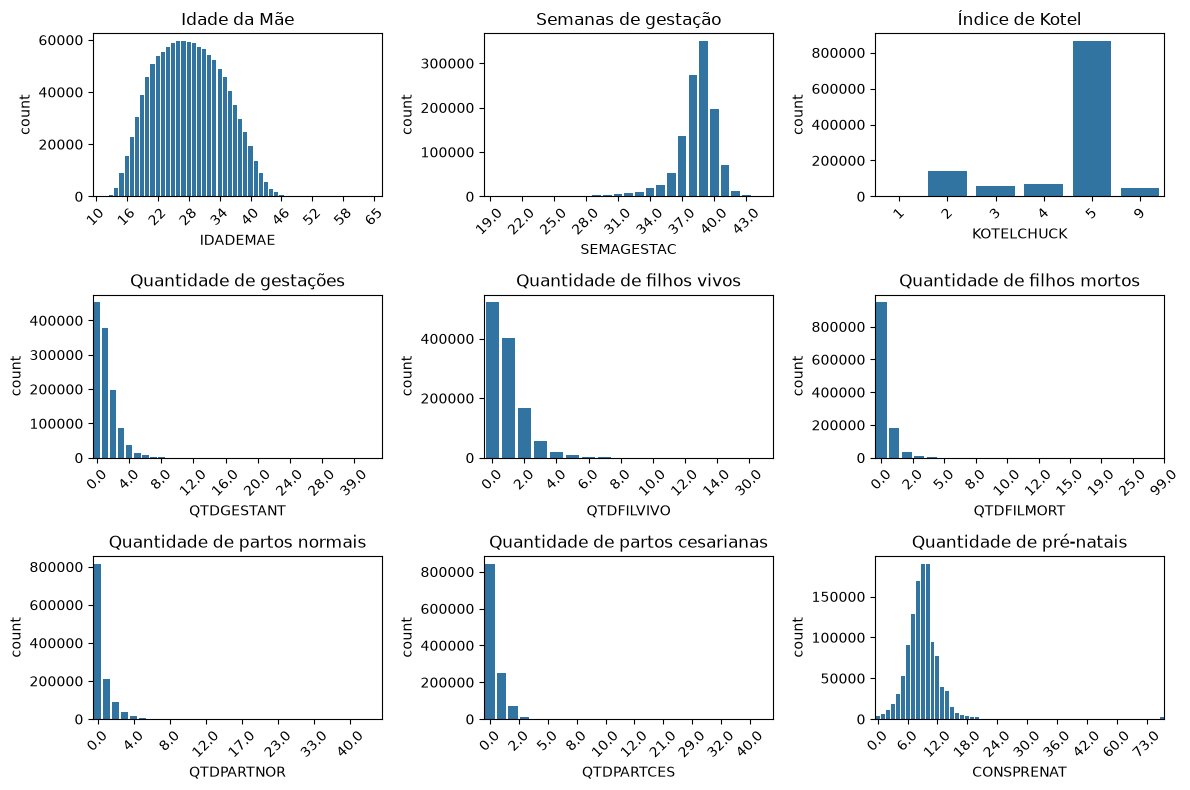

In [49]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

colunas_titulos = {
    'IDADEMAE': 'Idade da Mãe',
    'SEMAGESTAC': 'Semanas de gestação',
    'KOTELCHUCK': 'Índice de Kotel',
    'QTDGESTANT': 'Quantidade de gestações',
    'QTDFILVIVO': 'Quantidade de filhos vivos',
    'QTDFILMORT': 'Quantidade de filhos mortos',
    'QTDPARTNOR': 'Quantidade de partos normais',
    'QTDPARTCES': 'Quantidade de partos cesarianas',
    'CONSPRENAT': 'Quantidade de pré-natais',
}

for ax, (coluna, titulo) in zip(axes.flat, colunas_titulos.items()):
    sns.countplot(x=df[coluna], ax=ax)
    ax.set_title(titulo)
    if coluna == 'KOTELCHUCK':
        ax.xaxis.set_major_locator(ticker.MaxNLocator(6))
    else:
        ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **Conclusões:**
- **Idade da Mãe:** Distribuição comportada, formato de sino suavemente assimétrico à direita, com média de 24 à 28 anos, dentro do escopo esperado, avaliar extremos menor que 10 e maior que 65.
- **Semanas de Gestação:** Concentração forte em 37 à 40 semanas, com uma cauda suave até 28. Formato esperado clinicamente.
- **Índice de Kotelchuck:** Concentrado na categoria 5, indica um bom sinal de qualidade assistencial na base.
- **Quantidade de Gestações:** Fortemente concentrado em 0 à 2, padrão esperado. Avaliar valores acima de 15 gestações.
- **Quantidade de Filhos Vivos:** Concentração em 0-1, cauda até 30, avaliar os extremos.
- **Quantidade de Filhos Mortos:** Avaliar valores extremos.
- **Quantidade de Partos Normais/Cesáreos:** Forte concentração em 0 à 1.
- **Quantidade de Consultas Pré-natal:** Distribuição aproximadamente normal, concetrada em 6-9 consultas. Coerente com a recomendação de pré-natal adequado. Avaliar caudas extremas.

## Correlação

Vamos entender como as variáveis se correlacionam entre elas:

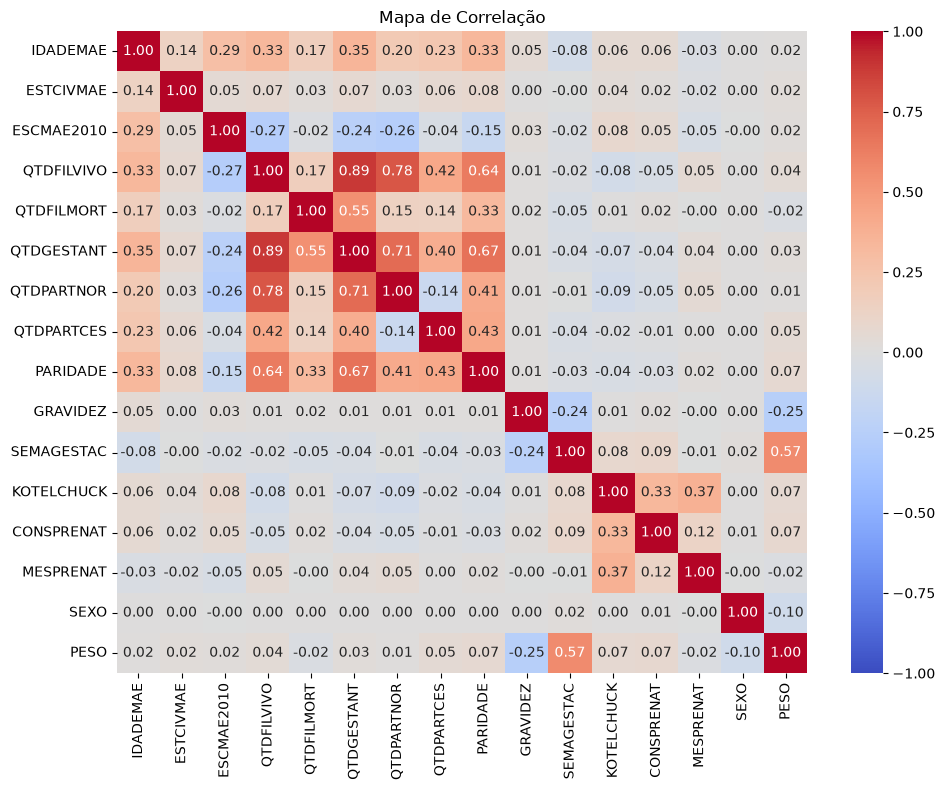

In [50]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Correlação')
plt.tight_layout()
plt.show()

### Relações importantes com o target

- A variável `SEMAGESTAC` tem uma forte relação, confirmando a hipótese qeu a quantidade de semanas tem forte relação com o peso.
- A quantidade de bebês por gestação, medida por `GRAVIDEZ`, se relaciona de forma negativa, portanto o peso individual de cada bebê é menor.
- O `SEXO` também indica uma relação fraca, indicando que meninos nascem pesando mais.
- `GRAVIDEZ` e `SEMAGESTAC`: -0.24, gravidez múltipla tende a nascer mais cedo, coerente com a literatura.

### Multicolinearidade entre as features

- `QTDFILVIVO` e `QTDGESTANT`: 0.89
- `QTDFILVIVO` e `QTDPARTOR`: 0.78
- `QTDGESTANT` e `PARIDADE`: 0.67
- `QTDGESTANT` e `QTDPARTNOR`: 0.71
- `QTDFILVIVO` e `PARIDADE`: 0.64
- `QTDGESTANT` e `QTDFILMORT`: 0.55

Isso era esperado, visto que todas medem quantas vezes essa mulher já passou por gestação/parto, entretando é problemático terem todas juntas no mesmo modelo linear. A decisão é deixar apenas `PARIDADE` e `QTDGESTANT`, ou aplicar PCA para manter todas.

### Demais correlações

- `ESCMAE2010` tem correlação negativa com as variáveis de contagem, `QTDFILVIVO`: -0,27, `QTDGESTANT`: -0,24, `QTDPARTNOR`: -0,26, `PARIDADE`: -0,15, indicando aquilo que é reformaçado pela literatura socioeconômica, mães com mais escolaridade tendem a ter menos filhos. Entretanto, `ESCMAE2010` já carrega parte da informação que essas variáveis de contagem trazem, sendo portanto redundante.
- `KOTELCHUCK` e `MESPRENAT`: 0.37, `KOTELCHUCK` e `CONSPRENAT`: 0.33, o índice é calculado a partir dessas duas variáveis, apresenta portanto uma necessidade de utilizar apenas duas variáveis e não as três.


## Análise bivariada


Assim como feito para cada variável, vamos entender como cada variável fica distribuída em relação ao peso.

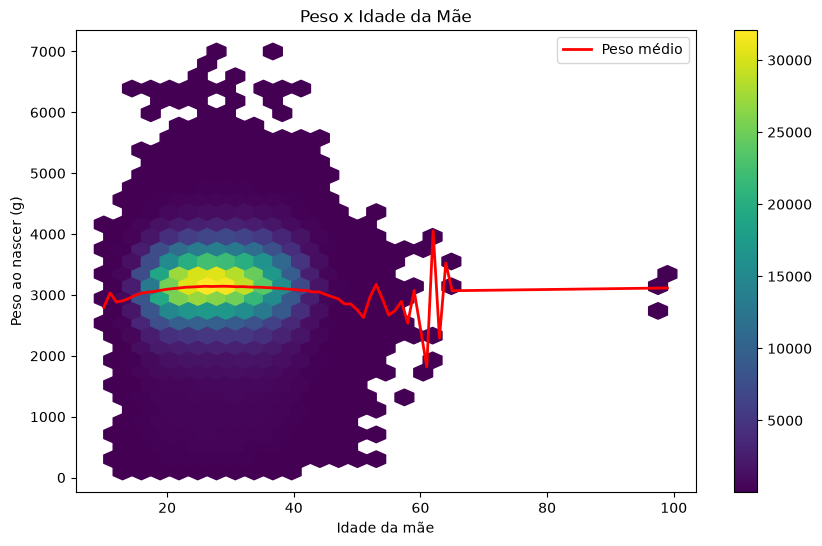

In [51]:

fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(df['IDADEMAE'], df['PESO'], gridsize=30, cmap='viridis', mincnt=1)
plt.colorbar(hb, ax=ax)

# Peso médio por idade (linha de tendência)
media_por_idade = df.groupby('IDADEMAE')['PESO'].mean()
ax.plot(media_por_idade.index, media_por_idade.values, color='red', linewidth=2, label='Peso médio')

ax.set_xlabel('Idade da mãe')
ax.set_ylabel('Peso ao nascer (g)')
ax.set_title('Peso x Idade da Mãe')
ax.legend()
plt.show()

Com a linha peso médio, verificamos a hipotese em U, com o peso crescendo até os 30 anos de forma consistente, mas depois disso fica praticamente dos 30 a 50 anos, sem mostrar de forma clara uma queda, e após 55 anos, a curva vira ruido.

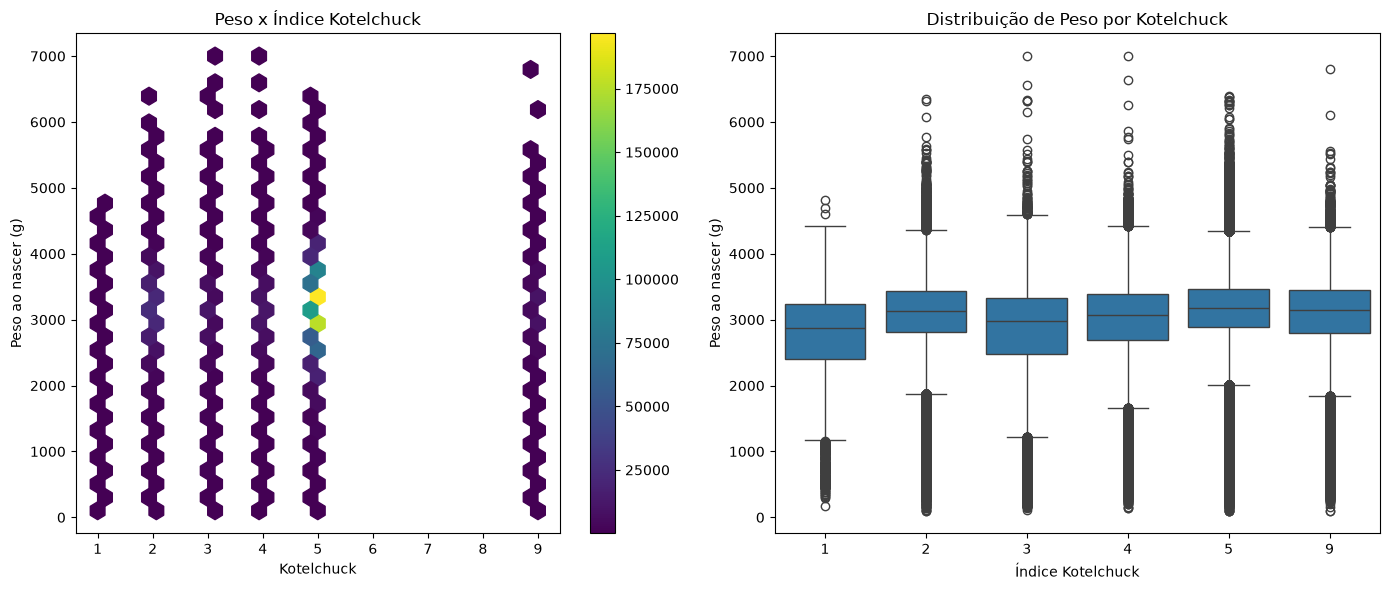

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hexbin
hb = axes[0].hexbin(df['KOTELCHUCK'], df['PESO'], gridsize=30, cmap='viridis', mincnt=1)
fig.colorbar(hb, ax=axes[0])
axes[0].set_xlabel('Kotelchuck')
axes[0].set_ylabel('Peso ao nascer (g)')
axes[0].set_title('Peso x Índice Kotelchuck')

# Boxplot
sns.boxplot(x='KOTELCHUCK', y='PESO', data=df, ax=axes[1])
axes[1].set_xlabel('Índice Kotelchuck')
axes[1].set_ylabel('Peso ao nascer (g)')
axes[1].set_title('Distribuição de Peso por Kotelchuck')

plt.tight_layout()
plt.show()

A categoria 1, de pior pré-natal, tem a mediana mais baixa entre todas, o que bate com a expectativa, mas a parit da categoria 2 em diante as medianas ficam muito próximas, média entre 3000 e 3200g, até a categoria 5. A dispersão é parecida entre todas as categorias sem redução de variancia esperada nas categorias de pré-natal mais adequado.

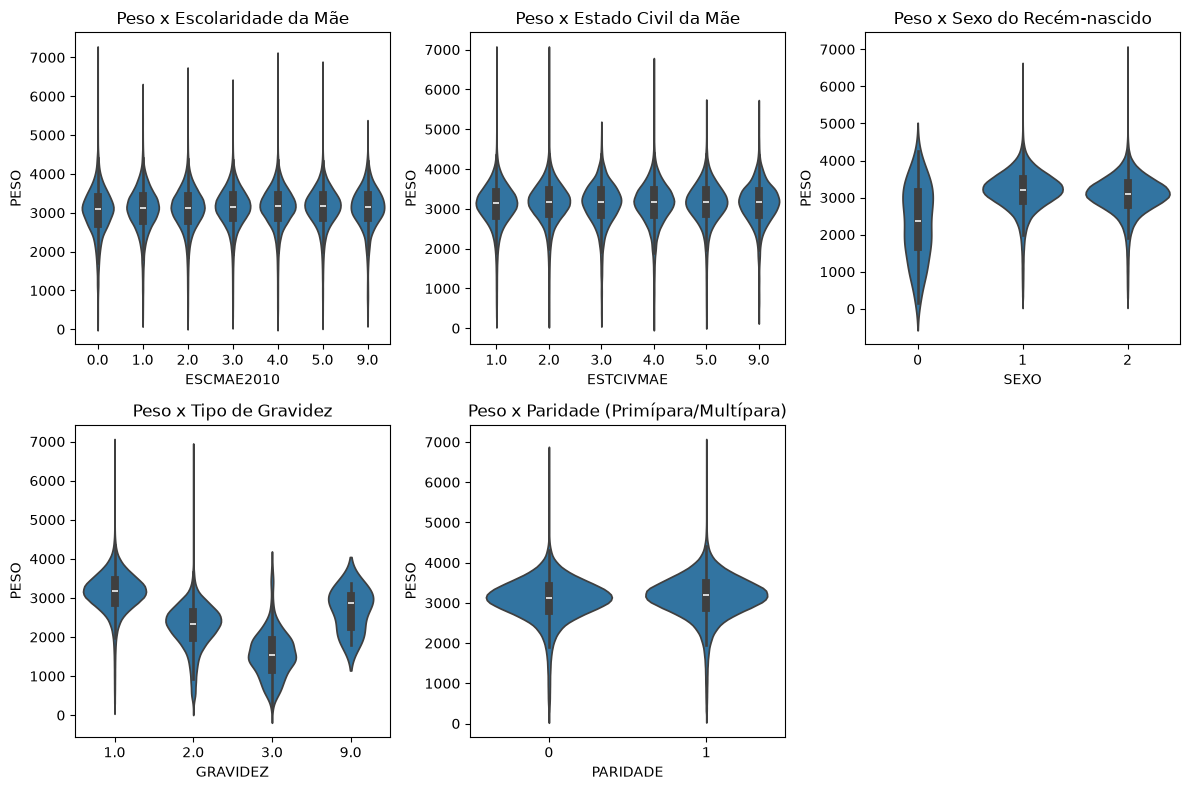

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

colunas_titulos = {
    'ESCMAE2010': 'Escolaridade da Mãe',
    'ESTCIVMAE': 'Estado Civil da Mãe',
    'SEXO': 'Sexo do Recém-nascido',
    'GRAVIDEZ': 'Tipo de Gravidez',
    'PARIDADE': 'Paridade (Primípara/Multípara)'
}

for ax, (coluna, titulo) in zip(axes.flat, colunas_titulos.items()):
    sns.violinplot(x=df[coluna], y=df['PESO'], ax=ax)
    ax.set_title(f'Peso x {titulo}')
    ax.tick_params(axis='x')

# esconde o subplot vazio
for ax in axes.flat[len(colunas_titulos):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Escolaridade da mãe:** Efeito bem sutil do esperado, revelando que escolaridade capture menos informação isolada do que outras variáveis já mostram, ou que o efeito socioeconômico esteja mais concetrado em outras features.  

**Estado civil da mãe:** O padrão se repete, as distribuições quase sobrepostas, sem diferença visual relevante nas medianas, o resultado é um efeito muito sútil.  

**Sexo:** A categoria de idade 0, o que deveria ser ignorado, tem uma distribuição visualmente deslocada para baixo, com mediana bem mais baixa. Isso sugere que pode estar relacionada com partos de maior risco. As categorias 1 e 2 mostram diferença pequena, com masculino levemente mais alto.  

**Tipo de gravidez:** Confirma que existe uma queda do peso quando há gestações com mais de uma criança.  

**Paridade:** Diferença muita pequena entre as duas.  

**Raça/Cor e Raça/Cor da mãe:** Sem diferença visual entre ambas as categorias, remover essas variáveis.


### Investigando resultados ignorados e ambíguos

In [54]:
# Gravidez e sexo
print(df['SEXO'].value_counts())
print(df['GRAVIDEZ'].value_counts())

SEXO
1    602375
2    575624
0       135
Name: count, dtype: int64
GRAVIDEZ
1.0    1148851
2.0      28566
3.0        706
9.0         11
Name: count, dtype: int64


- Decisão: remover valores 0 e 9 de sexo e gravidez.

In [55]:
# proporçao de idade mae maior que 55 e menor que 11
print(df['IDADEMAE'].gt(55).value_counts(normalize=True))
print(df['IDADEMAE'].lt(11).value_counts(normalize=True))

IDADEMAE
False    0.99998
True     0.00002
Name: proportion, dtype: float64
IDADEMAE
False    0.999997
True     0.000003
Name: proportion, dtype: float64


- Decisão: remover valores extremos.

In [56]:
for col, teto in {'QTDFILMORT': 10, 'QTDGESTANT': 15, 'QTDFILVIVO': 15,
                   'QTDPARTNOR': 15, 'QTDPARTCES': 15, 'CONSPRENAT': 20,
                   'IDADEMAE': 55}.items():
    n_acima = (df[col] > teto).sum()
    print(f'{col}: {n_acima} registros acima de {teto} ({n_acima/len(df)*100:.3f}%)')

QTDFILMORT: 43 registros acima de 10 (0.004%)
QTDGESTANT: 54 registros acima de 15 (0.005%)
QTDFILVIVO: 5 registros acima de 15 (0.000%)
QTDPARTNOR: 40 registros acima de 15 (0.003%)
QTDPARTCES: 41 registros acima de 15 (0.003%)
CONSPRENAT: 4807 registros acima de 20 (0.408%)
IDADEMAE: 23 registros acima de 55 (0.002%)


- Decisão: remover valores extremos.

## Feature Engineering

### **Removendo valores extremos e ignorados**

In [57]:
# Condição
condicoes_exclusao = (
    (df['SEXO'] == 0) |
    (df['GRAVIDEZ'] == 9) |
    (df['IDADEMAE'] < 10) | (df['IDADEMAE'] > 55) |
    (df['QTDFILMORT'] > 10) |
    (df['QTDGESTANT'] > 15) |
    (df['QTDFILVIVO'] > 15) |
    (df['QTDPARTNOR'] > 15) |
    (df['QTDPARTCES'] > 15) |
    ((df['CONSPRENAT'] > 30) & (df['CONSPRENAT'].notna())) |
    (df['MESPRENAT'] == 99)
)

# Aplica a remoção
df = df[~condicoes_exclusao].copy()

### **Multicolinearidade**

A variável `QTDGESTANT` contempla a totalidade de gestações, incluindo vivos, mortos e abortos, `QTDFILVIVO` é um subconjunto, vale o mesmo para `QTDFILMORT`, mas conceitualmente diferente indicando risco obstétrico. `QTDPARTNOR` E `QTDPARTCES` são subconjuntos de `QTDFILVIVO` e `PARIDADE` representra `QTDGESTANT` > 0. Portanto, as únicas variáveis realmente relevantes são `QTDGESTANT` por representar a variável mais completa do bloco e `QTDFILMORT` pois representa um sinal de risco clínico específico que `QTDGESTANT` não capta.  

Podemos confirmar por uma análise do VIF:

In [58]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

bloco = ['QTDFILVIVO', 'QTDFILMORT', 'QTDGESTANT', 'QTDPARTNOR', 'QTDPARTCES', 'PARIDADE']
X = df[bloco].dropna()

vif = pd.DataFrame()
vif['variavel'] = bloco
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(bloco))]
print(vif)

     variavel        VIF
0  QTDFILVIVO  52.854274
1  QTDFILMORT   9.808993
2  QTDGESTANT  71.303253
3  QTDPARTNOR  20.666750
4  QTDPARTCES   9.948908
5    PARIDADE   3.697104


Aqui, a variável `QTDGESTANT` consegue ser explicada em mais de 90% da variância das demais variaveis, enqanto a `PARIDADE` quase não consegue ser explicada.

In [59]:
bloco = ['QTDFILMORT', 'QTDGESTANT']
X = df[bloco].dropna()

vif = pd.DataFrame()
vif['variavel'] = bloco
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(bloco))]
print(vif)

     variavel       VIF
0  QTDFILMORT  1.701727
1  QTDGESTANT  1.701727


Quando avaliamos o VIF apenas das duas variáveis, encontramos um valor aceitável < 5%. Portanto, vamos permanecer apenas com `QTDGESTANT` e `QTDFILMORT`.

In [60]:
bloco = ['QTDFILVIVO', 'QTDPARTNOR', 'QTDPARTCES', 'PARIDADE']
df = df.drop(columns=bloco)

A mesma lógica aplicada anteriormente deve permanecer ao analisar o índice kotelchuck com as variáveis de `CONSTPRENAT` e `MESPRENAT`, visto que o índice é composto pelas duas, vamos decidir olhando para o valor do VIF:

In [61]:

trio = ['KOTELCHUCK', 'CONSPRENAT', 'MESPRENAT']
X = df[trio].dropna()

vif = pd.DataFrame()
vif['variavel'] = trio
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(trio))]
print(vif)

     variavel        VIF
0  KOTELCHUCK  11.532625
1  CONSPRENAT  12.204535
2   MESPRENAT   2.571756


Com um VIF acima de 5%, vamos ter q escolher eliminar `CONSPRENAT` ou `MESPRENAT`, no caso a escolha se voltou para `CONSPRENAT` visto que carrega menos informação e é mais redundante, VIF final:

In [62]:

trio = ['KOTELCHUCK', 'MESPRENAT']
X = df[trio].dropna()

vif = pd.DataFrame()
vif['variavel'] = trio
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(trio))]
print(vif)

     variavel       VIF
0  KOTELCHUCK  2.401751
1   MESPRENAT  2.401751


In [63]:
# Removendo
df = df.drop(columns='CONSPRENAT')

In [64]:
# Definindo o mes, preenchendo valores com a mediana e criando a temporada
def mes_temporada(mes):
    if mes in [12, 1, 2]:
        return 'V'
    elif mes in [3, 4, 5]:
        return 'O'
    elif mes in [6, 7, 8]:
        return 'I'
    elif mes in [9, 10, 11]:
        return 'P'

df['MES'] = df['DTNASC'].astype(str).str.split('-').str[1].astype(float)
df['ANO'] = df['DTNASC'].astype(str).str.split('-').str[0]
median_mes = df['MES'].median()
df['MES'] = df['MES'].fillna(median_mes).astype(int)
df['TEMPORADA'] = df['MES'].apply(mes_temporada)

# Removendo a data de nascimento
df = df.drop(columns='DTNASC')

In [65]:
# Aplicando o one hot encoding para ESTCIVMAE
df['ESTCIVMAE'] = df['ESTCIVMAE'].replace({9: 3})
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['ESTCIVMAE']])

cols = encoder.get_feature_names_out(['ESTCIVMAE'])
df_encoded = pd.DataFrame(encoded, columns=cols, index=df.index)

df = pd.concat([df, df_encoded], axis=1)
df = df.drop(columns=['ESTCIVMAE'])

In [66]:
# Aplicando o one hot encoding para GRAVIDEZ
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['GRAVIDEZ']])

cols = encoder.get_feature_names_out(['GRAVIDEZ'])
df_encoded = pd.DataFrame(encoded, columns=cols, index=df.index)

df = pd.concat([df, df_encoded], axis=1)
df = df.drop(columns=['GRAVIDEZ'])

In [67]:
# Aplicando o one hot encoding para KOTELCHUCK
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[['KOTELCHUCK']])

cols = encoder.get_feature_names_out(['KOTELCHUCK'])
df_encoded = pd.DataFrame(encoded, columns=cols, index=df.index)

df = pd.concat([df, df_encoded], axis=1)
df = df.drop(columns=['KOTELCHUCK'])

In [68]:
# Aplicando stantarscaler a IDADEMAE, SEMAGESTAC, QTDGESTANT e QTDFILMORT
scaler = StandardScaler()
df[['IDADEMAE', 'SEMAGESTAC', 'QTDGESTANT', 'QTDFILMORT']] = scaler.fit_transform(df[['IDADEMAE', 'SEMAGESTAC', 'QTDGESTANT', 'QTDFILMORT']])

## Modelo

Foi adotado o split temporal, então vamos utilizar os dados de treino para os anos de 2020-2023 e testar o modelo com os dados de 2024, pois dessa forma não existe aprendizado de padrão futuro com vazamento de previsão evitando uma maior performance artificialmente.

In [81]:
# Divisão de treino e teste
train = df[df['ANO'].isin(['2020', '2021', '2022', '2023'])]
test = df[df['ANO'] == '2024']

In [82]:
# Separando features e target 
X_train, y_train = train.drop(columns=['PESO']), train['PESO']
X_test, y_test = test.drop(columns=['PESO']), test['PESO']